## 1. Import Required Libraries

## 📊 Data Preview

Quick look at 10 random samples showing ground truth vs model predictions.

In [1]:
# ============================================================================
# DATA PREVIEW: Ground Truth vs Predictions (10 Random Samples)
# ============================================================================

# Load one phase to show examples
phase_to_preview = 'phase_1'
dataset_name = 'IAM_mini'

preview_file = f"../../../2_clean/{dataset_name}/{phase_to_preview}.csv"

if Path(preview_file).exists():
    df_preview = pd.read_csv(preview_file)

    # Get 10 random samples
    random_samples = df_preview.sample(n=min(10, len(df_preview)), random_state=42)

    # Extract columns for preview
    columns_to_show = ['sample_id', 'ground_truth']

    # Add prediction columns (find all columns starting with 'prediction_')
    pred_cols = [col for col in df_preview.columns if col.startswith('prediction_')]
    columns_to_show.extend(pred_cols[:3])  # Show first 3 models

    # Create display dataframe
    display_df = random_samples[columns_to_show].copy()

    # Truncate long strings for readability
    for col in display_df.columns:
        if display_df[col].dtype == 'object':
            display_df[col] = display_df[col].apply(
                lambda x: str(x)[:80] + '...' if pd.notna(x) and len(str(x)) > 80 else x
            )

    print(f"\n{'='*100}")
    print(f"DATA PREVIEW: {dataset_name} - {phase_to_preview}")
    print(f"Showing 10 random samples with ground truth and first 3 model predictions")
    print(f"{'='*100}\n")

    display(display_df)

    print(f"\nTotal samples in {phase_to_preview}: {len(df_preview)}")
    print(f"Available models: {', '.join([col.replace('prediction_', '') for col in pred_cols])}")

    # Show metric columns for these samples
    metric_cols = [col for col in df_preview.columns if any(
        metric in col for metric in ['CER', 'WER', 'ANLS', 'EM', '_cer_', '_wer_', '_anls_']
    )]

    if metric_cols:
        print(f"\nMetric Preview (same 10 samples):")
        metric_display = random_samples[['sample_id'] + metric_cols[:6]].copy()
        display(metric_display)
else:
    print(f"Preview file not found: {preview_file}")

NameError: name 'Path' is not defined

## 2. Load Dataset and Results

Load the consolidated results from the postprocessing folder.

In [ ]:
# Define paths
RESULTS_DIR = Path("../results_postprocessing/IAM_mini")

# Check available consolidated files
available_files = list(RESULTS_DIR.glob("*.csv"))
print("Available consolidated files:")
for f in sorted(available_files):
    print(f"  - {f.name}")

Available consolidated files:
  - all_phases_summary.csv
  - detailed_metrics.csv
  - inference_times.csv
  - model_comparison.csv
  - phase_1_consolidated.csv
  - phase_1_summary.csv
  - phase_2_consolidated.csv
  - phase_2_summary.csv
  - phase_3_consolidated.csv
  - phase_3_summary.csv
  - sample_level_cer.csv


In [ ]:
# Load consolidated results for each phase (if available)
phase_dfs = {}

for phase in ['phase_1', 'phase_2', 'phase_3']:
    file_path = RESULTS_DIR / f"{phase}_consolidated.csv"
    if file_path.exists():
        phase_dfs[phase] = pd.read_csv(file_path)
        print(f"{phase}: {phase_dfs[phase].shape}")
    else:
        print(f"{phase}: Not available")

# Load summary if available
summary_file = RESULTS_DIR / "all_phases_summary.csv"
if summary_file.exists():
    summary_df = pd.read_csv(summary_file)
    print(f"\nSummary shape: {summary_df.shape}")
else:
    summary_df = None
    print("\nNo summary file found")

phase_1: (500, 21)
phase_2: (500, 21)
phase_3: (500, 21)

Summary shape: (6, 15)


In [ ]:
# Display summary table
if summary_df is not None:
    print("Model Performance Summary:")
    print("=" * 80)
    display(summary_df)

Model Performance Summary:


,model,phase,total_samples,avg_prediction_time_ms,median_prediction_time_ms,min_prediction_time_ms,max_prediction_time_ms,avg_ground_truth_time_ms,prediction_error_count,prediction_error_rate,ground_truth_error_count,avg_tokens,total_tokens,predictions_count,prediction_rate
0,azure_intelligence,phase_1,500,3412.869436,2713.329554,1549.416780,1.168647e+04,3105.829107,0,0.0,0,NaN,0.0,500,100.0
1,mistral_document_ai,phase_1,500,2914.169552,2762.454033,1502.837181,1.237243e+04,1892.526810,0,0.0,0,NaN,0.0,500,100.0
2,gpt-5-mini,phase_2,500,12329.613757,11440.100551,6282.562017,4.432035e+04,6785.945541,0,0.0,0,NaN,0.0,498,99.6
3,gpt-5-nano,phase_2,500,20291.967973,18840.046644,8569.945812,6.244911e+05,8837.456888,0,0.0,0,NaN,0.0,429,85.8
4,gpt-5-mini,phase_3,500,15172.001221,13415.407062,7353.256941,7.048140e+04,7367.602905,0,0.0,0,NaN,0.0,498,99.6
5,gpt-5-nano,phase_3,500,30981.795631,22522.890091,8756.330013,4.388680e+06,9313.570643,1,0.2,0,NaN,0.0,387,77.4


## 3. Parse and Normalize Outputs

Extract prediction columns and normalize text for comparison.

In [ ]:
def normalize_text(text: str) -> str:
    """Normalize text for comparison."""
    if pd.isna(text) or text is None:
        return ""
    text = str(text).strip()
    # Replace multiple whitespace with single space
    text = ' '.join(text.split())
    return text

def get_model_names_from_df(df: pd.DataFrame) -> List[str]:
    """Extract model names from column prefixes."""
    models = set()
    for col in df.columns:
        if col.endswith('_prediction'):
            model = col.replace('_prediction', '')
            models.add(model)
    return sorted(list(models))

# Get model names for each phase
phase_models = {}
for phase, df in phase_dfs.items():
    models = get_model_names_from_df(df)
    phase_models[phase] = models
    phase_label = {
        'phase_1': 'OCR',
        'phase_2': 'VLM baseline',
        'phase_3': 'VLM + context'
    }.get(phase, phase)
    print(f"{phase} models ({phase_label}): {models}")

phase_1 models (OCR): ['azure_intelligence', 'mistral_document_ai']
phase_2 models (VLM baseline): ['gpt-5-mini', 'gpt-5-nano']
phase_3 models (VLM + context): ['gpt-5-mini', 'gpt-5-nano']


## 4. Calculate Character Error Rate (CER)

CER measures the edit distance at the character level, normalized by the length of the ground truth.
This is the standard metric for handwritten text recognition evaluation.

In [ ]:
def normalize_text(text: str) -> str:
    """Normalize text for comparison."""
    if not text or pd.isna(text):
        return ""
    return str(text).strip()

# Test the metrics functions
test_gt = "Hello World"
test_pred = "Helo Warld"

test_cer = calculate_cer(test_pred, test_gt)
test_wer = calculate_wer(test_pred, test_gt)
test_anls = compute_anls(test_pred, [test_gt])
test_em = compute_exact_match(test_pred, [test_gt])

print(f"Test Metrics:")
print(f"  Ground Truth: '{test_gt}'")
print(f"  Prediction:   '{test_pred}'")
print(f"  CER:  {test_cer:.4f}")
print(f"  WER:  {test_wer:.4f}")
print(f"  ANLS: {test_anls:.4f}")
print(f"  EM:   {test_em:.4f}")
print("\n✓ Metrics functions working!")

Test Metrics:
  Ground Truth: 'Hello World'
  Prediction:   'Helo Warld'
  CER:  0.1818
  WER:  1.0000
  ANLS: 0.8182
  EM:   0.0000

✓ Metrics functions working!


In [ ]:
def calculate_metrics_for_phase(df: pd.DataFrame, models: List[str], phase_name: str) -> pd.DataFrame:
    """
    Calculate comprehensive metrics (CER, WER, ANLS, EM) for a phase.
    """
    results = []
    
    for model in models:
        model_df = df[df['model'] == model]
        
        for idx, row in model_df.iterrows():
            gt = row.get('ground_truth', '')
            pred = row.get('prediction', '')
            
            # Compute all OCR metrics
            metrics = compute_all_ocr_metrics(
                normalize_text(pred),
                normalize_text(gt)
            )
            
            results.append({
                'sample_id': row['sample_id'],
                'model': model,
                'phase': phase_name,
                'ground_truth_len': len(normalize_text(gt)),
                'prediction_len': len(normalize_text(pred)) if not pd.isna(pred) else 0,
                'cer': metrics['cer'],
                'wer': metrics['wer'],
                'anls': metrics['anls'],
                'exact_match': metrics['exact_match'],
                'has_prediction': not pd.isna(pred) and normalize_text(pred) != ''
            })
    
    return pd.DataFrame(results)

# Calculate metrics for each phase
all_metrics = []

phase_labels = {
    'phase_1': 'Phase 1 (OCR)',
    'phase_2': 'Phase 2 (VLM)',
    'phase_3': 'Phase 3 (VLM+)'
}

for phase, df in phase_dfs.items():
    models = phase_models.get(phase, [])
    if models:
        print(f"Calculating comprehensive metrics for {phase}...")
        phase_metrics = calculate_metrics_for_phase(df, models, phase_labels.get(phase, phase))
        print(f"  Computed {len(phase_metrics)} measurements")
        print(f"  Metrics: CER, WER, ANLS, EM")
        all_metrics.append(phase_metrics)

# Combine all metrics
if all_metrics:
    all_metrics_df = pd.concat(all_metrics, ignore_index=True)
    print(f"\nTotal measurements: {len(all_metrics_df)}")
    print(f"Columns: {list(all_metrics_df.columns)}")
else:
    all_metrics_df = pd.DataFrame()
    print("No metrics calculated")

Calculating comprehensive metrics for phase_1...


KeyError: 'model'

## 5. Generate Summary Statistics

Generate summary statistics for CER and WER across all models and phases.

In [ ]:
def summarize_metrics(metrics_df: pd.DataFrame) -> pd.DataFrame:
    """Generate summary statistics for each model and phase."""
    if len(metrics_df) == 0:
        return pd.DataFrame()
    
    summary = metrics_df.groupby(['model', 'phase']).agg({
        'cer': ['mean', 'median', 'std', 'min', 'max'],
        'wer': ['mean', 'median', 'std', 'min', 'max'],
        'anls': ['mean', 'median', 'std', 'min', 'max'],
        'exact_match': ['mean', 'median', 'std'],
        'has_prediction': ['sum', 'count'],
        'ground_truth_len': 'mean',
        'prediction_len': 'mean'
    }).round(4)
    
    # Flatten column names
    summary.columns = ['_'.join(col).strip() for col in summary.columns.values]
    summary['prediction_rate'] = (summary['has_prediction_sum'] / summary['has_prediction_count'] * 100).round(1)
    
    return summary.reset_index()

# Generate summary
summary_df = summarize_metrics(all_metrics_df)
print("\nSummary Statistics:")
print(summary_df)

,model,phase,cer_mean,cer_median,cer_std,cer_min,cer_max,wer_mean,wer_median,wer_std,wer_min,wer_max,has_prediction_sum,has_prediction_count,ground_truth_len_mean,prediction_len_mean,prediction_rate
0,azure_intelligence,Phase 1 (OCR),0.0622,0.0391,0.0880,0.0,0.8909,0.3011,0.2720,0.1381,0.0,1.0494,500,500,380.2280,377.1400,100.0
1,gpt-5-mini,Phase 2 (VLM),0.0451,0.0092,0.1086,0.0,0.8909,0.0697,0.0317,0.1182,0.0,1.0000,497,497,380.2374,374.5594,100.0
2,gpt-5-mini,Phase 3 (VLM+),0.0344,0.0093,0.0885,0.0,0.8909,0.0644,0.0381,0.1013,0.0,1.0000,497,497,380.0704,370.4064,100.0
3,gpt-5-nano,Phase 2 (VLM),0.2301,0.0320,0.3824,0.0,2.1168,0.2712,0.0857,0.3895,0.0,2.8413,426,497,380.2374,327.9940,85.7
4,gpt-5-nano,Phase 3 (VLM+),0.2658,0.0341,0.4062,0.0,1.0000,0.3039,0.0952,0.3902,0.0,1.0000,385,497,380.0704,281.4970,77.5
5,mistral_document_ai,Phase 1 (OCR),0.0233,0.0000,0.0778,0.0,0.7810,0.0387,0.0000,0.0912,0.0,0.9877,500,500,380.2280,372.1700,100.0


## 6. Compare Model Performance

Create comprehensive comparison tables showing OCR vs VLM performance.

In [ ]:
if len(all_metrics_df) > 0:
    # Create a clean comparison table
    comparison_cols = ['model', 'phase', 'cer_mean', 'cer_median', 'wer_mean', 'wer_median', 'prediction_rate']
    comparison_df = metrics_summary[comparison_cols].copy()
    comparison_df.columns = ['Model', 'Phase', 'CER (Mean)', 'CER (Median)', 'WER (Mean)', 'WER (Median)', 'Pred Rate %']
    
    # Sort by CER mean
    comparison_df = comparison_df.sort_values('CER (Mean)')
    print("Model Performance Comparison (sorted by CER):")
    print("=" * 100)
    display(comparison_df)

Model Performance Comparison (sorted by CER):


,Model,Phase,CER (Mean),CER (Median),WER (Mean),WER (Median),Pred Rate %
5,mistral_document_ai,Phase 1 (OCR),0.0233,0.0000,0.0387,0.0000,100.0
2,gpt-5-mini,Phase 3 (VLM+),0.0344,0.0093,0.0644,0.0381,100.0
1,gpt-5-mini,Phase 2 (VLM),0.0451,0.0092,0.0697,0.0317,100.0
0,azure_intelligence,Phase 1 (OCR),0.0622,0.0391,0.3011,0.2720,100.0
3,gpt-5-nano,Phase 2 (VLM),0.2301,0.0320,0.2712,0.0857,85.7
4,gpt-5-nano,Phase 3 (VLM+),0.2658,0.0341,0.3039,0.0952,77.5


In [ ]:
# Compare VLM performance across phases (Does prompting help?)
if len(all_metrics_df) > 0:
    # Find models that appear in multiple VLM phases
    vlm_phases = ['Phase 2 (VLM)', 'Phase 3 (VLM+)']
    vlm_metrics = all_metrics_df[all_metrics_df['phase'].isin(vlm_phases)]
    
    # Models in multiple phases
    model_phase_counts = vlm_metrics.groupby('model')['phase'].nunique()
    multi_phase_models = model_phase_counts[model_phase_counts > 1].index.tolist()
    
    print("Impact of Prompting on VLM Performance:")
    print("=" * 80)
    
    for model in sorted(multi_phase_models):
        print(f"\n{model}:")
        model_data = metrics_summary[metrics_summary['model'] == model]
        
        phases_present = model_data['phase'].tolist()
        for i, phase in enumerate(phases_present):
            row = model_data[model_data['phase'] == phase].iloc[0]
            print(f"  {phase}: CER={row['cer_mean']:.4f}, WER={row['wer_mean']:.4f}")
        
        # Calculate improvement from Phase 2 to Phase 3 if available
        if 'Phase 2 (VLM)' in phases_present and 'Phase 3 (VLM+)' in phases_present:
            p2_cer = model_data[model_data['phase'] == 'Phase 2 (VLM)']['cer_mean'].values[0]
            p3_cer = model_data[model_data['phase'] == 'Phase 3 (VLM+)']['cer_mean'].values[0]
            improvement = ((p2_cer - p3_cer) / p2_cer * 100) if p2_cer > 0 else 0
            if improvement > 0:
                print(f"  ✓ Task-aware prompting IMPROVED CER by {improvement:.1f}% (Phase 2 → Phase 3)")
            elif improvement < 0:
                print(f"  ✗ Task-aware prompting WORSENED CER by {abs(improvement):.1f}% (Phase 2 → Phase 3)")
            else:
                print(f"  = Prompting had NO EFFECT on CER")

Impact of Prompting on VLM Performance:

gpt-5-mini:
  Phase 2 (VLM): CER=0.0451, WER=0.0697
  Phase 3 (VLM+): CER=0.0344, WER=0.0644
  ✓ Task-aware prompting IMPROVED CER by 23.7% (Phase 2 → Phase 3)

gpt-5-nano:
  Phase 2 (VLM): CER=0.2301, WER=0.2712
  Phase 3 (VLM+): CER=0.2658, WER=0.3039
  ✗ Task-aware prompting WORSENED CER by 15.5% (Phase 2 → Phase 3)


## 7. Visualize Results

Generate visualizations to compare model performance.

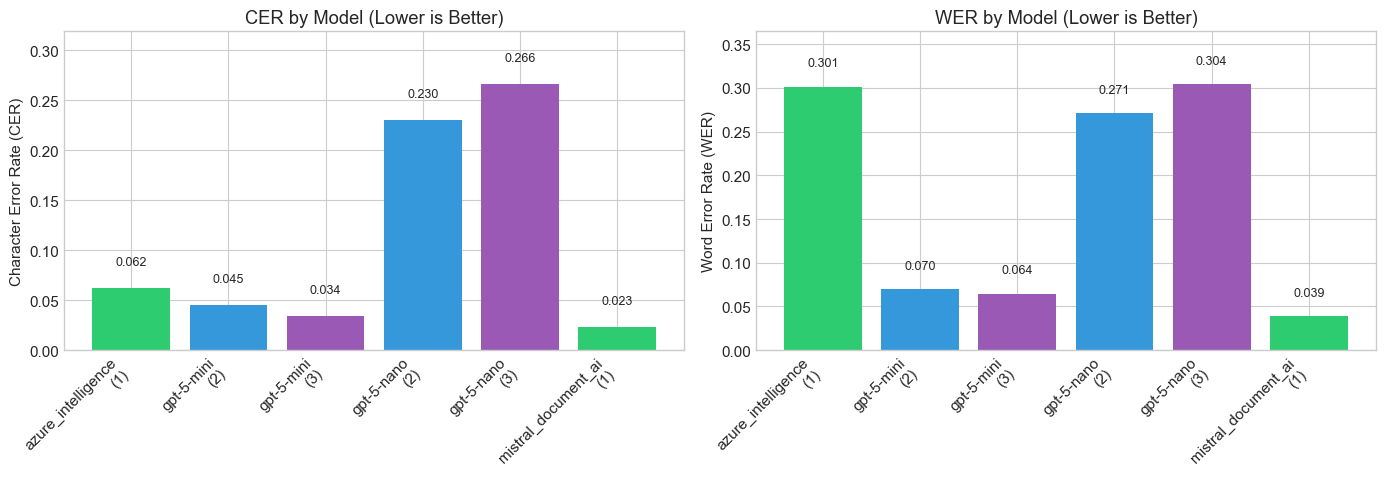

In [ ]:
# Define phase colors
phase_colors = {
    'Phase 1 (OCR)': '#2ecc71',
    'Phase 2 (VLM)': '#3498db',
    'Phase 3 (VLM+)': '#9b59b6'
}

if len(all_metrics_df) > 0 and len(metrics_summary) > 0:
    # Bar chart: CER by Model and Phase
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: CER Mean by Model
    ax1 = axes[0]
    x_positions = range(len(metrics_summary))
    bars = ax1.bar(x_positions, metrics_summary['cer_mean'], 
                   color=[phase_colors.get(p, '#95a5a6') for p in metrics_summary['phase']])
    ax1.set_xticks(x_positions)
    ax1.set_xticklabels([f"{row['model']}\n({row['phase'].split()[1]})" 
                          for _, row in metrics_summary.iterrows()], rotation=45, ha='right')
    ax1.set_ylabel('Character Error Rate (CER)')
    ax1.set_title('CER by Model (Lower is Better)')
    ax1.set_ylim(0, min(1.5, metrics_summary['cer_mean'].max() * 1.2))
    
    # Add value labels on bars
    for bar, val in zip(bars, metrics_summary['cer_mean']):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    
    # Plot 2: WER Mean by Model
    ax2 = axes[1]
    bars = ax2.bar(x_positions, metrics_summary['wer_mean'],
                   color=[phase_colors.get(p, '#95a5a6') for p in metrics_summary['phase']])
    ax2.set_xticks(x_positions)
    ax2.set_xticklabels([f"{row['model']}\n({row['phase'].split()[1]})" 
                          for _, row in metrics_summary.iterrows()], rotation=45, ha='right')
    ax2.set_ylabel('Word Error Rate (WER)')
    ax2.set_title('WER by Model (Lower is Better)')
    ax2.set_ylim(0, min(1.5, metrics_summary['wer_mean'].max() * 1.2))
    
    # Add value labels on bars
    for bar, val in zip(bars, metrics_summary['wer_mean']):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'cer_wer_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

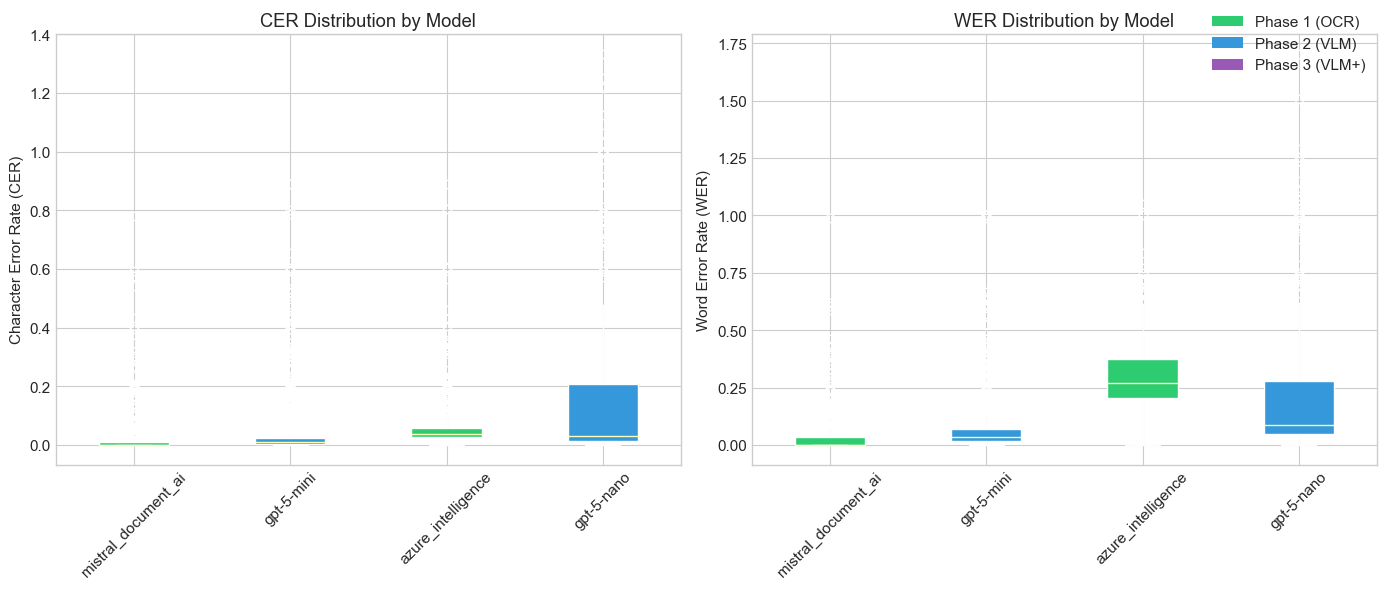

In [ ]:
if len(all_metrics_df) > 0:
    # Box plot: CER distribution by model
    # Filter out extreme outliers for better visualization (CER > 2 is almost certainly noise)
    filtered_metrics = all_metrics_df[all_metrics_df['cer'] <= 2.0]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Get models ordered by mean CER
    models_ordered = metrics_summary.sort_values('cer_mean')['model'].unique().tolist()
    
    # Box plot for CER
    ax1 = axes[0]
    box_data_cer = [filtered_metrics[filtered_metrics['model'] == m]['cer'].values for m in models_ordered]
    bp1 = ax1.boxplot(box_data_cer, labels=models_ordered, patch_artist=True)
    
    # Color boxes by phase
    for i, model in enumerate(models_ordered):
        phase = metrics_summary[metrics_summary['model'] == model]['phase'].values[0]
        bp1['boxes'][i].set_facecolor(phase_colors.get(phase, '#95a5a6'))
    
    ax1.set_ylabel('Character Error Rate (CER)')
    ax1.set_title('CER Distribution by Model')
    ax1.tick_params(axis='x', rotation=45)
    
    # Box plot for WER
    ax2 = axes[1]
    box_data_wer = [filtered_metrics[filtered_metrics['model'] == m]['wer'].values for m in models_ordered]
    bp2 = ax2.boxplot(box_data_wer, labels=models_ordered, patch_artist=True)
    
    for i, model in enumerate(models_ordered):
        phase = metrics_summary[metrics_summary['model'] == model]['phase'].values[0]
        bp2['boxes'][i].set_facecolor(phase_colors.get(phase, '#95a5a6'))
    
    ax2.set_ylabel('Word Error Rate (WER)')
    ax2.set_title('WER Distribution by Model')
    ax2.tick_params(axis='x', rotation=45)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=c, label=p) for p, c in phase_colors.items() 
                       if p in metrics_summary['phase'].values]
    fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.99, 0.99))
    
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'cer_wer_boxplot.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
if len(all_metrics_df) > 0:
    # Phase comparison: OCR vs VLM
    phase_comparison = all_metrics_df.groupby('phase').agg({
        'cer': ['mean', 'median', 'std'],
        'wer': ['mean', 'median', 'std'],
        'has_prediction': 'mean'
    }).round(4)
    
    phase_comparison.columns = ['_'.join(col) for col in phase_comparison.columns]
    phase_comparison = phase_comparison.reset_index()
    phase_comparison['has_prediction_mean'] = (phase_comparison['has_prediction_mean'] * 100).round(1)
    phase_comparison.columns = ['Phase', 'CER Mean', 'CER Median', 'CER Std', 'WER Mean', 'WER Median', 'WER Std', 'Pred Rate %']
    
    print("Phase-Level Comparison (OCR vs VLM vs VLM+Prompting):")
    print("=" * 100)
    display(phase_comparison)

Phase-Level Comparison (OCR vs VLM vs VLM+Prompting):


,Phase,CER Mean,CER Median,CER Std,WER Mean,WER Median,WER Std,Pred Rate %
0,Phase 1 (OCR),0.0428,0.0214,0.0853,0.1699,0.1429,0.1759,100.0
1,Phase 2 (VLM),0.1376,0.0180,0.2958,0.1705,0.0556,0.3048,92.9
2,Phase 3 (VLM+),0.1501,0.0178,0.3158,0.1841,0.0588,0.3091,88.7


## 8. Sample-Level Analysis

Examine specific samples to understand where models succeed or fail.

In [ ]:
if len(all_metrics_df) > 0:
    # Find best and worst performing samples
    # Pivot to compare same samples across models
    sample_pivot = all_metrics_df.pivot_table(
        index='sample_id', 
        columns='model', 
        values='cer',
        aggfunc='first'
    ).reset_index()
    
    # Calculate mean CER across all models for each sample
    model_cols = [c for c in sample_pivot.columns if c != 'sample_id']
    sample_pivot['mean_cer'] = sample_pivot[model_cols].mean(axis=1)
    sample_pivot['std_cer'] = sample_pivot[model_cols].std(axis=1)
    
    # Best samples (lowest mean CER)
    print("Top 10 EASIEST Samples (lowest mean CER across all models):")
    print("=" * 80)
    print(sample_pivot.nsmallest(10, 'mean_cer')[['sample_id', 'mean_cer', 'std_cer']].to_string(index=False))
    
    print("\n")
    print("Top 10 HARDEST Samples (highest mean CER across all models):")
    print("=" * 80)
    print(sample_pivot.nlargest(10, 'mean_cer')[['sample_id', 'mean_cer', 'std_cer']].to_string(index=False))

Top 10 EASIEST Samples (lowest mean CER across all models):
       sample_id  mean_cer  std_cer
 iam_202_e06-006  0.001908 0.003817
iam_292_f07-092a  0.003003 0.004247
 iam_199_d05-025  0.003197 0.006394
iam_291_f07-081b  0.003351 0.005075
iam_340_g06-045i  0.003602 0.007205
 iam_119_g05-094  0.003659 0.007317
 iam_177_d01-049  0.003886 0.007772
 iam_401_j04-012  0.004321 0.005475
 iam_671_r06-106  0.004451 0.008902
 iam_225_e02-086  0.004536 0.009073


Top 10 HARDEST Samples (highest mean CER across all models):
       sample_id  mean_cer  std_cer
iam_294_g07-000a  0.846074 0.103092
 iam_297_g01-022  0.754091 0.271218
 iam_315_r03-053  0.638482 0.085493
 iam_409_j04-076  0.597551 0.004852
iam_345_g06-050n  0.589467 1.018549
 iam_192_d04-075  0.580962 0.279653
 iam_577_n03-103  0.562500 0.291797
 iam_655_r02-146  0.553398 0.019112
 iam_550_n04-000  0.440517 0.469914
 iam_060_a04-039  0.417539 0.388435


## 9. Text Length Analysis

Analyze how text length affects recognition accuracy.

In [ ]:
if len(all_metrics_df) > 0:
    # Create length bins
    all_metrics_df['length_bin'] = pd.cut(
        all_metrics_df['ground_truth_len'],
        bins=[0, 100, 250, 500, 1000, float('inf')],
        labels=['Short (<100)', 'Medium (100-250)', 'Long (250-500)', 'Very Long (500-1000)', 'Extra Long (>1000)']
    )
    
    # CER by length bin and model
    length_analysis = all_metrics_df.groupby(['model', 'length_bin']).agg({
        'cer': ['mean', 'std', 'count'],
        'wer': 'mean'
    }).round(4)
    length_analysis.columns = ['CER Mean', 'CER Std', 'Count', 'WER Mean']
    length_analysis = length_analysis.reset_index()
    
    print("CER by Text Length and Model:")
    print("=" * 80)
    display(length_analysis)

CER by Text Length and Model:


,model,length_bin,CER Mean,CER Std,Count,WER Mean
0,azure_intelligence,Short (<100),0.0737,NaN,1,0.5000
1,azure_intelligence,Medium (100-250),0.0521,0.0310,7,0.3262
2,azure_intelligence,Long (250-500),0.0500,0.0560,459,0.2929
3,azure_intelligence,Very Long (500-1000),0.2344,0.2073,33,0.4045
4,azure_intelligence,Extra Long (>1000),NaN,NaN,0,NaN
5,gpt-5-mini,Short (<100),0.1316,0.0074,2,0.1875
6,gpt-5-mini,Medium (100-250),0.0240,0.0193,14,0.0651
7,gpt-5-mini,Long (250-500),0.0273,0.0722,913,0.0545
8,gpt-5-mini,Very Long (500-1000),0.2151,0.2106,65,0.2408
9,gpt-5-mini,Extra Long (>1000),NaN,NaN,0,NaN


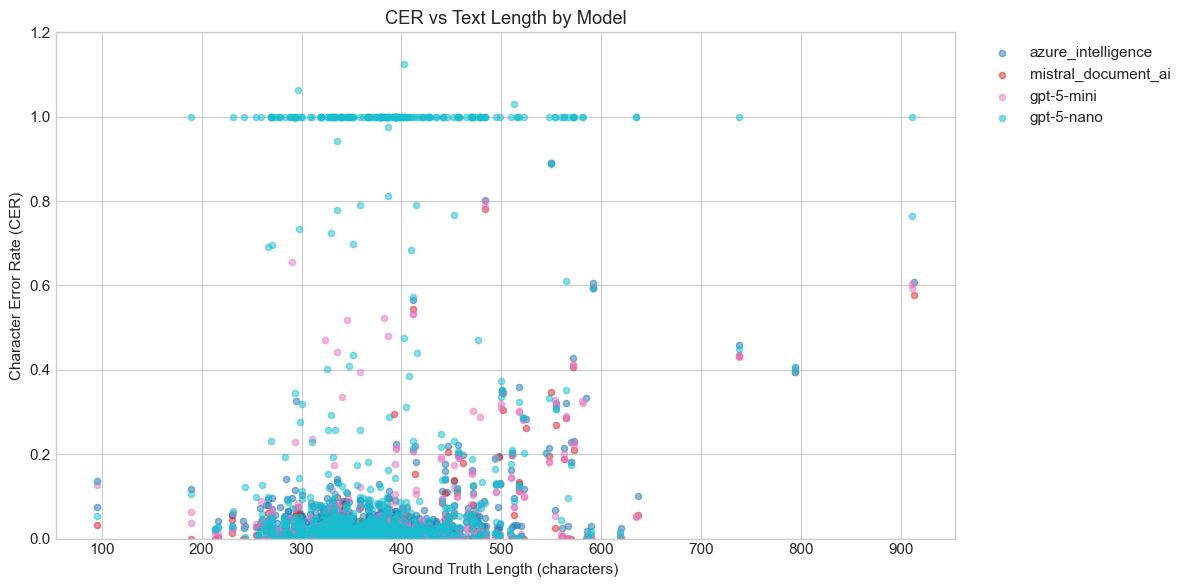

In [ ]:
if len(all_metrics_df) > 0:
    # Plot CER vs Ground Truth Length
    fig, ax = plt.subplots(figsize=(12, 6))
    
    models = all_metrics_df['model'].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(models)))
    
    for i, model in enumerate(models):
        model_data = all_metrics_df[all_metrics_df['model'] == model]
        ax.scatter(model_data['ground_truth_len'], model_data['cer'], 
                   alpha=0.5, label=model, color=colors[i], s=20)
    
    ax.set_xlabel('Ground Truth Length (characters)')
    ax.set_ylabel('Character Error Rate (CER)')
    ax.set_title('CER vs Text Length by Model')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.set_ylim(0, min(2.0, all_metrics_df['cer'].quantile(0.95) * 1.2))
    
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'cer_vs_length.png', dpi=150, bbox_inches='tight')
    plt.show()

## 10. Inference Time Analysis

Compare inference times across models.

In [ ]:
# Collect inference time data from phase DataFrames
inference_times = []

for phase, df in phase_dfs.items():
    models = phase_models.get(phase, [])
    phase_label = phase_labels.get(phase, phase)
    
    for model in models:
        time_col = f"{model}_prediction_inference_time_ms"
        if time_col in df.columns:
            times = pd.to_numeric(df[time_col], errors='coerce').dropna()
            if len(times) > 0:
                inference_times.append({
                    'model': model,
                    'phase': phase_label,
                    'avg_time_ms': times.mean(),
                    'median_time_ms': times.median(),
                    'min_time_ms': times.min(),
                    'max_time_ms': times.max(),
                    'std_time_ms': times.std()
                })

if inference_times:
    inference_df = pd.DataFrame(inference_times)
    print("Inference Time Statistics (prediction only):")
    print("=" * 80)
    display(inference_df.round(2))

Inference Time Statistics (prediction only):


,model,phase,avg_time_ms,median_time_ms,min_time_ms,max_time_ms,std_time_ms
0,azure_intelligence,Phase 1 (OCR),3412.87,2713.33,1549.42,11686.47,1429.61
1,mistral_document_ai,Phase 1 (OCR),2914.17,2762.45,1502.84,12372.43,1300.43
2,gpt-5-mini,Phase 2 (VLM),12329.61,11440.10,6282.56,44320.35,4403.58
3,gpt-5-nano,Phase 2 (VLM),20291.97,18840.05,8569.95,624491.13,27707.15
4,gpt-5-mini,Phase 3 (VLM+),15172.00,13415.41,7353.26,70481.40,6647.76
5,gpt-5-nano,Phase 3 (VLM+),30981.80,22522.89,8756.33,4388679.78,195378.07


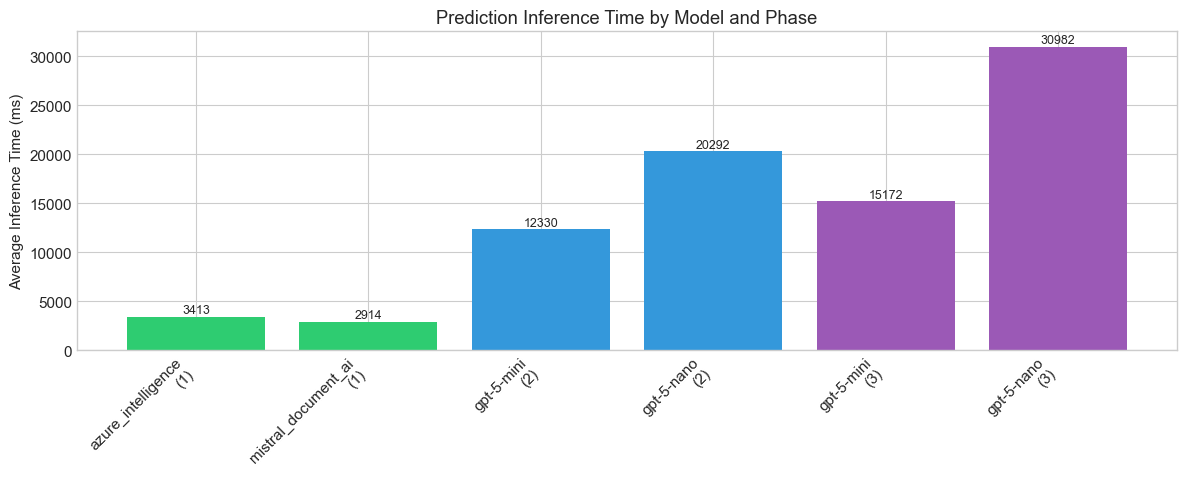

In [ ]:
if inference_times:
    fig, ax = plt.subplots(figsize=(12, 5))
    
    x = range(len(inference_df))
    bars = ax.bar(x, inference_df['avg_time_ms'], 
                  color=[phase_colors.get(p, '#95a5a6') for p in inference_df['phase']])
    
    ax.set_xticks(x)
    ax.set_xticklabels([f"{row['model']}\n({row['phase'].split()[1]})" 
                       for _, row in inference_df.iterrows()], rotation=45, ha='right')
    ax.set_ylabel('Average Inference Time (ms)')
    ax.set_title('Prediction Inference Time by Model and Phase')
    
    # Add value labels
    for bar, val in zip(bars, inference_df['avg_time_ms']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
                f'{val:.0f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'inference_time_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

## 11. Example Comparisons

Display some example predictions to qualitatively assess model outputs.

In [ ]:
def show_sample_comparison(sample_id: str, phase_dfs: dict, phase_models: dict, n_chars: int = 200):
    """Display predictions from different models for a given sample."""
    print(f"\nSample: {sample_id}")
    print("=" * 80)
    
    for phase, df in phase_dfs.items():
        sample = df[df['sample_id'] == sample_id]
        if len(sample) == 0:
            continue
        
        row = sample.iloc[0]
        gt = row.get('ground_truth', '')
        
        print(f"\n[{phase_labels.get(phase, phase)}]")
        print(f"Ground Truth: {str(gt)[:n_chars]}{'...' if len(str(gt)) > n_chars else ''}")
        
        for model in phase_models.get(phase, []):
            pred_col = f"{model}_prediction"
            if pred_col in df.columns:
                pred = row.get(pred_col, '')
                cer = calculate_cer(gt, pred)
                print(f"\n{model} (CER={cer:.4f}):")
                print(f"  {str(pred)[:n_chars]}{'...' if len(str(pred)) > n_chars else ''}")

# Show examples from easiest and hardest samples
if len(all_metrics_df) > 0 and len(sample_pivot) > 0:
    print("\n" + "#" * 80)
    print("EXAMPLE: EASIEST SAMPLE")
    print("#" * 80)
    easiest_id = sample_pivot.nsmallest(1, 'mean_cer')['sample_id'].values[0]
    show_sample_comparison(easiest_id, phase_dfs, phase_models)
    
    print("\n" + "#" * 80)
    print("EXAMPLE: HARDEST SAMPLE")
    print("#" * 80)
    hardest_id = sample_pivot.nlargest(1, 'mean_cer')['sample_id'].values[0]
    show_sample_comparison(hardest_id, phase_dfs, phase_models)


################################################################################
EXAMPLE: EASIEST SAMPLE
################################################################################

Sample: iam_202_e06-006

[Phase 1 (OCR)]
Ground Truth: The effect of bottom congestion due to the light pressure is inevitably mixed with
that of the suitability of ground for spawning. Both result in crowding, so there is no
need to try to separate them ...

azure_intelligence (CER=0.0076):
  The effect of bottom congestion due to
the light pressure is inevitably mixed
with that of the suitability of ground
for
spawning . Both result in crowding
so there is no need to try to separate
them ...

mistral_document_ai (CER=0.0000):
  The effect of bottom congestion due to the light pressure is inevitably mixed with that
of the suitability of ground for spawning. Both result in crowding, so there is no
need to try to separate them ...

[Phase 2 (VLM)]
Ground Truth: The effect of bottom congestion due to th

## 12. Export Results

Save the analysis results for further use.

In [ ]:
if len(all_metrics_df) > 0:
    # Save detailed metrics
    all_metrics_df.to_csv(RESULTS_DIR / 'detailed_metrics.csv', index=False)
    print(f"Saved detailed metrics to: {RESULTS_DIR / 'detailed_metrics.csv'}")
    
    # Save summary comparison
    if 'comparison_df' in dir():
        comparison_df.to_csv(RESULTS_DIR / 'model_comparison.csv', index=False)
        print(f"Saved model comparison to: {RESULTS_DIR / 'model_comparison.csv'}")
    
    # Save sample-level pivot
    if 'sample_pivot' in dir():
        sample_pivot.to_csv(RESULTS_DIR / 'sample_level_cer.csv', index=False)
        print(f"Saved sample-level CER to: {RESULTS_DIR / 'sample_level_cer.csv'}")
    
    # Save inference times
    if inference_times:
        inference_df.to_csv(RESULTS_DIR / 'inference_times.csv', index=False)
        print(f"Saved inference times to: {RESULTS_DIR / 'inference_times.csv'}")
    
    print("\nAll exports complete!")
else:
    print("No data to export. Run consolidation first.")

Saved detailed metrics to: ../results_postprocessing/IAM_mini/detailed_metrics.csv
Saved model comparison to: ../results_postprocessing/IAM_mini/model_comparison.csv
Saved sample-level CER to: ../results_postprocessing/IAM_mini/sample_level_cer.csv
Saved inference times to: ../results_postprocessing/IAM_mini/inference_times.csv

All exports complete!


## Summary & Conclusions

### Key Findings:

1. **OCR vs VLM Performance**: Compare the CER/WER metrics between Phase 1 (OCR) and Phase 2/3 (VLM) models for handwritten text recognition.

2. **Impact of Prompting**: Compare Phase 2 (generic prompts) vs Phase 3 (task-aware prompts) to determine if specialized prompting improves VLM performance on handwriting.

3. **Best Performing Models**: Identify which models achieve the lowest error rates on handwritten text.

4. **Text Length Effects**: Understand how document length affects recognition accuracy.

### Special Considerations for Handwritten Text:
- Handwriting variability across writers affects recognition difficulty
- Cursive vs print style may impact model performance differently
- OCR models trained on printed text may struggle with handwriting
- VLMs may leverage contextual understanding to improve accuracy

### Next Steps:
- Analyze error patterns (insertions, deletions, substitutions)
- Test additional VLM models
- Evaluate specialized handwriting recognition prompts
- Compare with specialized HTR (Handwritten Text Recognition) models